In [1]:
import scipy.io as sio
import h5py
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import stft
from datetime import datetime
import os
import numpy as np
import pywt
%matplotlib inline

In [2]:
os.chdir("../")

In [3]:
%pwd

'c:\\Users\\Rounak\\Desktop\\OneDrive\\College\\Projects\\Privacy-Preserving-Human-Pose-Estimation-from-WiFi'

In [4]:
from dataclasses import dataclass
from pathlib import Path

@dataclass(frozen=True)
class DataTransformationConfig:
    root_dir: Path
    data_dir: Path

In [5]:
from PrivacyPreservingHumanPoseEstimationFromWiFi.utils.common import read_yaml, create_directories
from PrivacyPreservingHumanPoseEstimationFromWiFi.constants import *

In [6]:
class ConfigurationManager:
    def __init__(self, config_filepath = CONFIG_FILE_PATH, params_filepath = PARAMS_FILE_PATH):
        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)
        create_directories([self.config.artifacts_root])

    def get_data_transformation_config(self) -> DataTransformationConfig:
        config = self.config.data_transformation
        params = self.params.data_transformation
        create_directories([config.root_dir])

        data_transformation_config = DataTransformationConfig(
            root_dir = config.root_dir,
            data_dir = config.data_dir,
        )

        # data_transformation_params = DataTransformationParams(
        #     window_size = params.window_size,
        #     n_sigmas = params.n_sigmas,
        #     level = params.level,
        #     wavelet = params.wavelet,
        #     threshold = params.threshold,
        # )

        return data_transformation_config

In [7]:
mat_contents = sio.loadmat('Dataset/CSI dataset for wireless human sensing/dataset/AR-1a/AR1a_C.mat')

In [8]:
mat_contents.keys()

dict_keys(['__header__', '__version__', '__globals__', 'csi_buff'])

In [9]:
mat_contents['csi_buff']

array([[  76. +22.j,    4.  +0.j, -651.+427.j, ..., -286.+312.j,
        -351.+339.j,    0.  -6.j],
       [ -11.+124.j,   -7.  -6.j, -566. +37.j, ..., -522.+246.j,
        -532.+194.j,   11.  +2.j],
       [  57. +15.j,   -7.  +5.j,  443.+162.j, ...,  553.+544.j,
         569.+462.j,  -10.  -5.j],
       ...,
       [  47.+125.j,    5.  -8.j, -693. +86.j, ..., -406.+238.j,
        -479.+200.j,   18. -12.j],
       [  99. +12.j,   -3.  +4.j,  428. -31.j, ...,  820.+273.j,
         779.+209.j,    8.  -4.j],
       [ -61. +42.j,    9.  -8.j, -412.+184.j, ..., -680.+794.j,
        -598.+687.j,    0. +15.j]])

In [15]:
class DataTransformation:
    def __init__(self, config: DataTransformationConfig):
        self.config = config
        self.subfolders = []
        self.files = {}
        self.csi_data = []
    
    def get_csi_files(self):
        self.subfolders = [f.path for f in os.scandir(self.config.data_dir) if f.is_dir()]
        self.subfolders = [f for f in self.subfolders if f.split('\\').pop().startswith('AR')]
        for subfolder in self.subfolders:
            self.files[subfolder.split('\\').pop()] = [f.path for f in os.scandir(subfolder) if f.is_file()]
            self.files[subfolder.split('\\').pop()] = [f.replace('\\', '/') for f in self.files[subfolder.split('\\').pop()]]
        
    def get_csi_data(self, path):
        mat_contents = sio.loadmat(path)
        csi_data = pd.DataFrame.from_dict(mat_contents['csi_buff'])
        csi_data = csi_data.applymap(lambda x: np.angle(x))
        return csi_data
    
    def linear_transform(self, phase):
        return (phase + np.pi) / (2 * np.pi)

    def hampel_filter(self, data, window_size=5, n_sigmas=3):
        median = np.median(data)
        mad = np.median(np.abs(data - median))
        is_outlier = np.abs(data - median) > (n_sigmas * mad)
        data[is_outlier] = median  # Replace outliers with the median
        return data
    
    def denoise_signal(self, signal, level=3, wavelet='db4'):
        coeffs = pywt.wavedec(signal, wavelet, level=level)
        threshold = 0.3 * np.max(coeffs[0])  # Adjust threshold as needed
        denoised_coeffs = [pywt.threshold(c, threshold) for c in coeffs]
        denoised_signal = pywt.waverec(denoised_coeffs, wavelet)
        return denoised_signal
    
    # def data_transformation(self, csi_data):
    #     for column in csi_data:
    #         csi_data[column] = self.linear_transform(csi_data[column])
    #         csi_data[column] = self.hampel_filter(csi_data[column])
    #         csi_data[column] = self.denoise_signal(csi_data[column])
    #     return csi_data
    def data_transformation(self, csi_data):
        for row_idx in range(csi_data.shape[0]):
            csi_data.iloc[row_idx, :] = self.linear_transform(csi_data.iloc[row_idx, :])
            csi_data.iloc[row_idx, :] = self.hampel_filter(csi_data.iloc[row_idx, :])
            csi_data.iloc[row_idx, :] = self.denoise_signal(csi_data.iloc[row_idx, :])
        return csi_data

    
    def save_data(self, folder, filename, csi_data):
        print("Saving data in folder: " + folder + "...")
        if not os.path.exists(os.path.join(self.config.root_dir, folder)):
            os.makedirs(os.path.join(self.config.root_dir, folder))
        np.save(os.path.join(self.config.root_dir, folder, filename), csi_data)
        print("Data saved successfully!")
    
    def iterate_over_files(self):
        self.get_csi_files()
        for folder, filepaths in self.files.items():
            print("Now working on folder: " + folder)
            for filepath in filepaths:
                filename = filepath.split('/').pop()
                csi_data = self.get_csi_data(filepath)
                csi_data = self.data_transformation(csi_data)
            
                self.save_data(folder, filename, csi_data)
                csi_data = []


In [16]:
# folder, filename, csi_data = None, None, None
try:
    config = ConfigurationManager()
    data_transformation_config = config.get_data_transformation_config()
    data_transformation = DataTransformation(config = data_transformation_config)
    folder, filename, csi_data = data_transformation.iterate_over_files()

except Exception as e:
    raise e

[2024-01-05 18:47:19,610: INFO: common] Successfully read yaml file from config\config.yaml
[2024-01-05 18:47:19,615: INFO: common] Successfully read yaml file from params.yaml
[2024-01-05 18:47:19,619: INFO: common] Created directory at: artifacts
[2024-01-05 18:47:19,621: INFO: common] Created directory at: artifacts/data_transformation
Now working on folder: AR-1a
Saving data in folder: AR-1a...
Data saved successfully!
Saving data in folder: AR-1a...
Data saved successfully!


KeyboardInterrupt: 

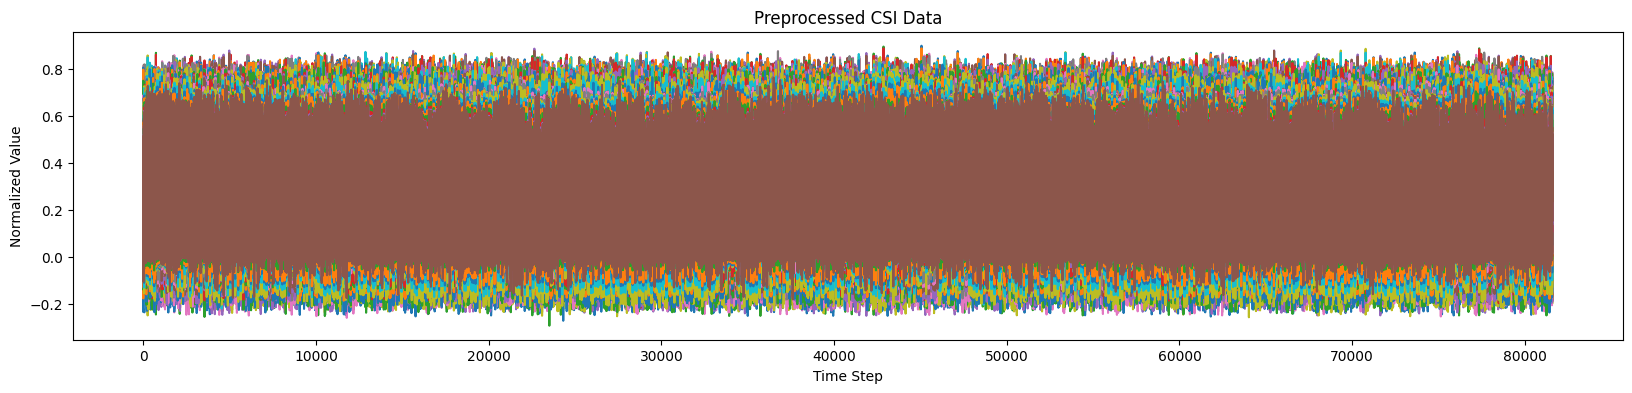

In [18]:
preprocessed_data = np.load('artifacts/data_transformation/AR-1a/AR1a_C.mat.npy')

def plot_preprocessed_data(preprocessed_data):
    plt.figure(figsize=(20, 4))
    for column in range(preprocessed_data.shape[1]):
        plt.plot(preprocessed_data[:, column], label=f'Feature {column + 1}')

    plt.title('Preprocessed CSI Data')
    plt.xlabel('Time Step')
    plt.ylabel('Normalized Value')  # Adjust the label based on your preprocessing
    # plt.legend()
    plt.show()

# Call the function to plot the preprocessed data
plot_preprocessed_data(preprocessed_data)

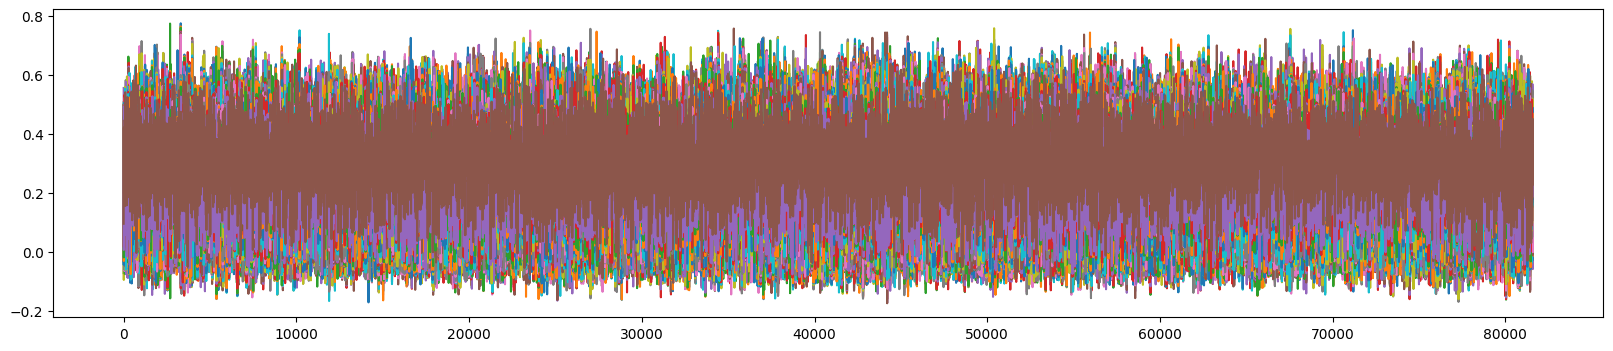

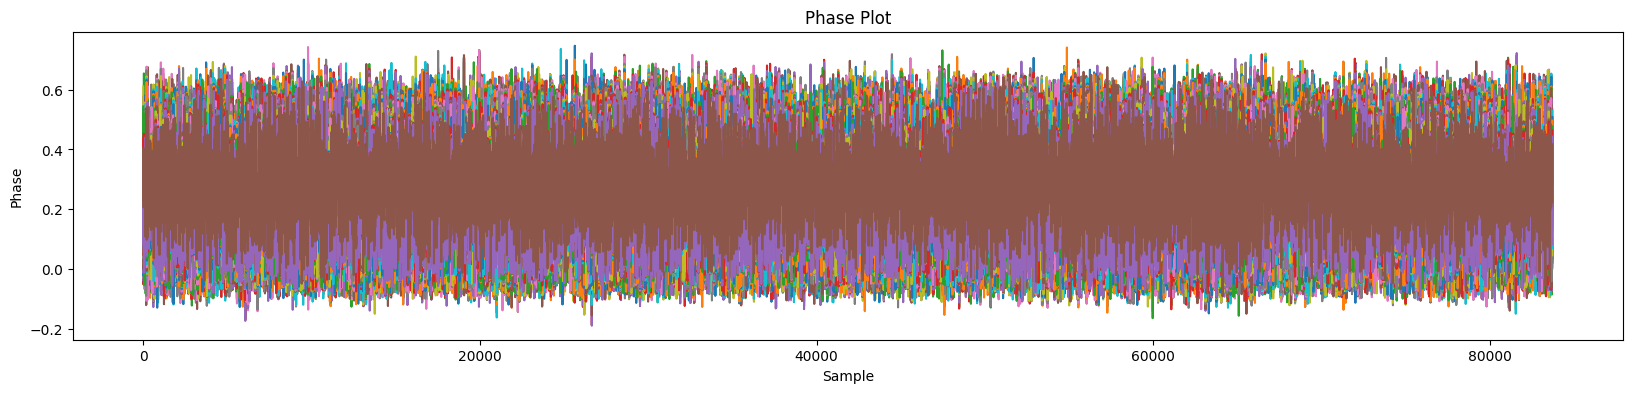

In [21]:
plt.figure(figsize=(20, 4))
plt.plot(data_transformation.activity_data['C'])
# plot one more data of key W
plt.figure(figsize=(20, 4))
plt.plot(data_transformation.activity_data['W'])
plt.title('Phase Plot')
plt.xlabel('Sample')
plt.ylabel('Phase')
plt.show()